In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
# from statsmodels.tsa.holtwinters import SimpleExpSmoothing
# import zipfile
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np


In [2]:
# Download the dataset
dataset_path = kagglehub.dataset_download("bhaveshsonagra/monthly-milk-production")
print("Dataset folder path:", dataset_path)

# Find CSV file dynamically
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_file = os.path.join(root, file)
            print("Found CSV file:", csv_file)
            break

100%|██████████| 962/962 [00:00<00:00, 2.01MB/s]

Extracting files...
Dataset folder path: /root/.cache/kagglehub/datasets/bhaveshsonagra/monthly-milk-production/versions/1
Found CSV file: /root/.cache/kagglehub/datasets/bhaveshsonagra/monthly-milk-production/versions/1/monthly-milk-production-pounds.csv


In [3]:
# Load dataset
df = pd.read_csv(csv_file)
df.head()

,Month,Monthly milk production: pounds per cow. Jan 62 ? Dec 75
0,1962-01,589.0
1,1962-02,561.0
2,1962-03,640.0
3,1962-04,656.0
4,1962-05,727.0


In [4]:
df.rename(columns={'Monthly milk production: pounds per cow. Jan 62 ? Dec 75': 'production'}, inplace=True)
df.head()

,Month,production
0,1962-01,589.0
1,1962-02,561.0
2,1962-03,640.0
3,1962-04,656.0
4,1962-05,727.0


In [5]:
df.tail()

,Month,production
164,1975-09,817.0
165,1975-10,827.0
166,1975-11,797.0
167,1975-12,843.0
168,Monthly milk production: pounds per cow. Jan 6...,NaN


In [6]:
df = df.iloc[:-1]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       168 non-null    object 
 1   production  168 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.8+ KB


In [8]:
df['Month'] = pd.to_datetime(df['Month'])

In [9]:
df.set_index('Month', inplace=True)
df.head()

,production
Month,
1962-01-01,589.0
1962-02-01,561.0
1962-03-01,640.0
1962-04-01,656.0
1962-05-01,727.0


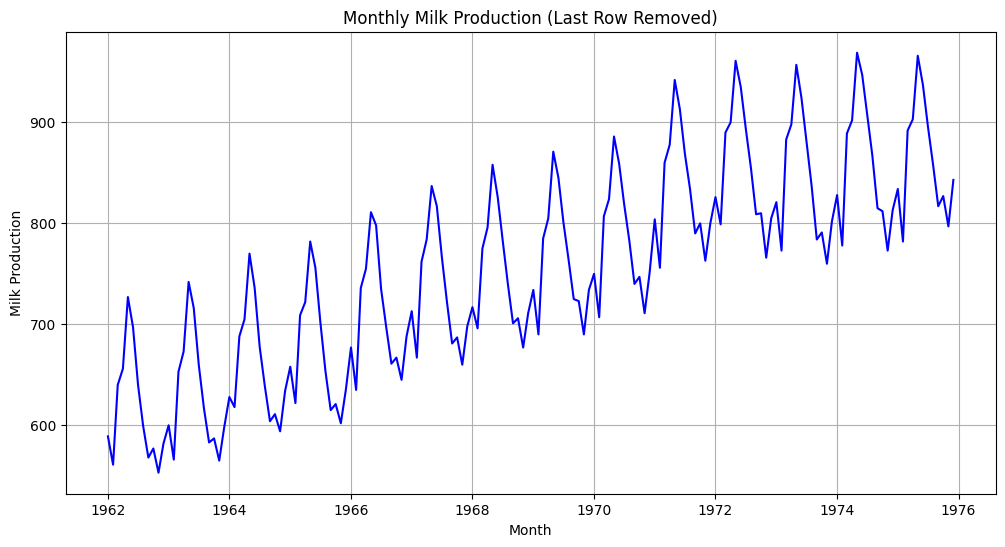

In [10]:
# Plot the line chart
plt.figure(figsize=(12,6))
plt.plot(df.index, df['production'], color='blue')
# plt.plot(df.index, df['production'], marker='o', linestyle='-', color='blue')
plt.title("Monthly Milk Production (Last Row Removed)")
plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

In [12]:
# Assume 'Month' is datetime index
train = df[df.index.year <= 1974]
test = df[df.index.year > 1974]

# Check sizes
print("Train size:", len(train))
print("Test size:", len(test))

# Optional: inspect
print(train.tail())
print(test.head())



Train size: 156
Test size: 12
            production
Month                 
1974-08-01       867.0
1974-09-01       815.0
1974-10-01       812.0
1974-11-01       773.0
1974-12-01       813.0
            production
Month                 
1975-01-01       834.0
1975-02-01       782.0
1975-03-01       892.0
1975-04-01       903.0
1975-05-01       966.0


In [ ]:
# Fit Holt-Winters model
# seasonal='add' for additive seasonality, seasonal_periods=12 for monthly data
hw_model = ExponentialSmoothing(
    train['production'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(len(test))
hw_forecast.index = test.index  # align forecast index with test

#Add fitted values to train DataFrame
train['HW_Fitted'] = hw_fit.fittedvalues

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-1799863053.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['HW_Fitted'] = hw_fit.fittedvalues


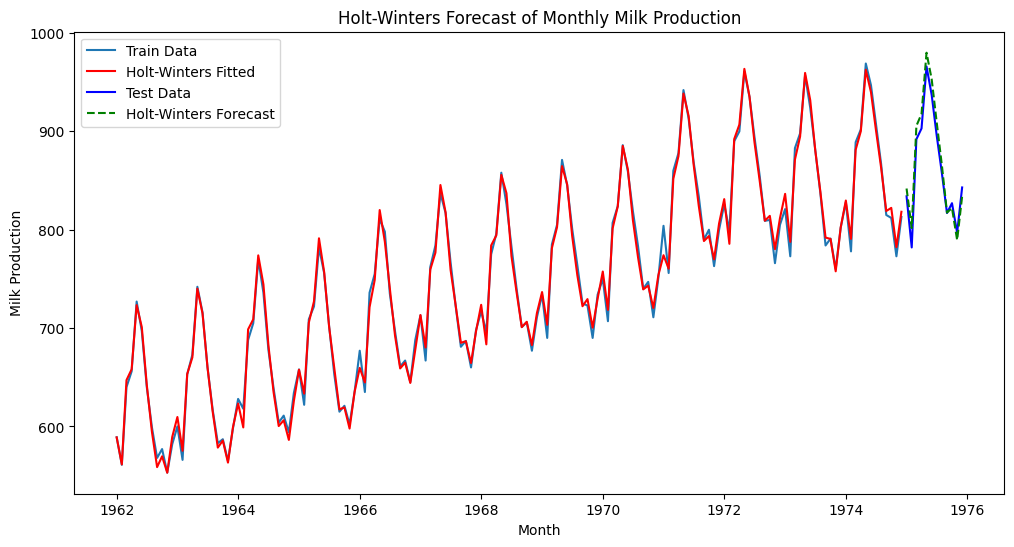

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train['production'], label='Train Data')
plt.plot(train['HW_Fitted'], label='Holt-Winters Fitted', color='red')
plt.plot(test['production'], label='Test Data', color='blue')
plt.plot(hw_forecast, label='Holt-Winters Forecast', color='green', linestyle='--')
plt.title("Holt-Winters Forecast of Monthly Milk Production")
plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

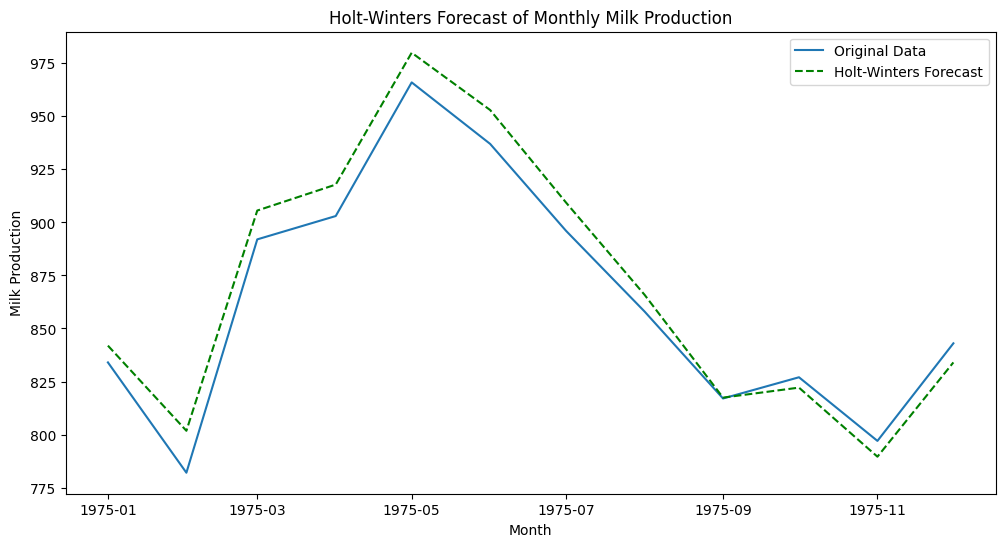

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(test, label='Original Data')
plt.plot(hw_forecast.index, hw_forecast.values, label='Holt-Winters Forecast', color='green', linestyle='--')
plt.title("Holt-Winters Forecast of Monthly Milk Production")
plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

# Compute MAE
mae = mean_absolute_error(test['production'], hw_forecast)
print(f"MAE on test set: {mae:.2f}")

MAE on test set: 10.75


In [ ]:
# Custom function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
mean_absolute_percentage_error(test['production'], hw_forecast)

np.float64(1.2367545124620927)